<a href="https://colab.research.google.com/github/dhruvbit/Machine-project/blob/main/torchvision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
all = ([[12.3,33.33,44.20],
        [23.22,34.22,19.48],
        [49.33,22.99,38.22]])



In [ ]:
all_value = torch.tensor((all),dtype=torch.float32)
print(all_value)

tensor([[12.3000, 33.3300, 44.2000],
        [23.2200, 34.2200, 19.4800],
        [49.3300, 22.9900, 38.2200]])


In [ ]:
all_values = all_value[:,1]
print(all_values)

tensor([33.3300, 34.2200, 22.9900])


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


In [ ]:
#Prepare your data: Load the MNIST dataset, inspect its format, and apply essential transformations.
#Build your model: Define a custom neural network using PyTorch’s flexible nn.Module class.
#Train your model: Implement the full training process with a loss function, optimizer, and training loop.
#Analyze your results: Evaluate your model on unseen data and visualize its performance.

In [ ]:
#check tpu gpu
if torch.cuda.is_available():
   device = torch.device("cuda")
   print(f"using CUDA")
elif torch.backend.mps.is_available():
  device = torch.device("mps")
  print(f"using mps ")

else:
  device = torch.device("cpu")
  print(f"using CPU")

using CUDA


In [ ]:
#60,000 training images and 10,000 test images. Each image is 28 by 28 pixels,
#in grayscale, showing a single handwritten digit from 0 to 9.

In [ ]:
data_path = "./data"

In [ ]:
train_dataset_without_transform = torchvision.datasets.MNIST(
    root=data_path,
    train=True,
    download=True
)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.56MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 128kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.8MB/s]


In [ ]:
image_pill,label = train_dataset_without_transform[0]
print(f"image type:  {type(image_pill)}")
print(f"image dimension:   {image_pill.size}")
print(f"Label Type:        {type(label)}")
print(f"Label value:       {label}")

image type:  <class 'PIL.Image.Image'>
image dimension:   (28, 28)
Label Type:        <class 'int'>
Label value:       5


In [ ]:
import random
import torch

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from PIL import Image

In [ ]:
def display_image(image, label, title, num_ticks=6, show_values=True):
    """
    Displays an image with its corresponding label and title.

    This function handles different image formats (PIL Image and PyTorch Tensor),
    normalizes the display range, and optionally overlays pixel values on the image.

    Args:
        image: The image data to be displayed. Can be a PIL Image or a PyTorch Tensor.
        label: The label associated with the image.
        title: The title for the plot.
        num_ticks (int, optional): The number of ticks to display on the color bar. Defaults to 6.
        show_values (bool, optional): If True, overlays the numerical value of each pixel on the image. Defaults to True.
    """
    # Initialize variables for value range and image data.
    vmin_val, vmax_val = None, None
    image_data = None

    # Check if the input is a PIL Image.
    if isinstance(image, Image.Image):
        # Set the value range for a standard 8-bit image.
        vmin_val = 0
        vmax_val = 255
        # Convert the PIL Image to a NumPy array.
        image_data = np.array(image)
    # Check if the input is a PyTorch Tensor.
    elif isinstance(image, torch.Tensor):
        # Convert the tensor to a NumPy array and remove any single-dimensional entries.
        image_np = image.numpy().squeeze()
        # Determine the min and max values from the tensor for normalization.
        vmin_val = image_np.min()
        vmax_val = image_np.max()
        # Assign the NumPy array to image_data.
        image_data = image_np
    # Handle unsupported image types.
    else:
        print("Warning: Unsupported image type.")
        return

    # Create a new figure for the plot.
    plt.figure(figsize=(9, 9))
    # Display the image data as a grayscale image.
    plt.imshow(image_data, cmap='gray', vmin=vmin_val, vmax=vmax_val)
    # Set the title of the plot with the provided title and label.
    plt.title(f'{title} | Label: {label}')

    # Check if pixel values should be displayed on the image.
    if show_values:
        # Calculate a threshold to determine the color of the text (black or white).
        threshold = (vmin_val + vmax_val) / 2.0
        # Get the dimensions of the image.
        height, width = image_data.shape

        # Iterate over each pixel to display its value.
        for y in range(height):
            for x in range(width):
                # Get the pixel value.
                value = image_data[y, x]
                # Set text color based on the pixel's brightness.
                text_color = "white" if value < threshold else "black"

                # Format the text to display, handling integers and floats differently.
                text_to_display = f"{value:.0f}" if isinstance(value, np.integer) else f"{value:.1f}"

                # Add the pixel value as text to the plot.
                plt.text(x, y, text_to_display,
                         ha="center", va="center", color=text_color, fontsize=6)

    # Add a grid to the plot.
    plt.grid(True, color='red', alpha=0.3, zorder=2)
    # Set the x-axis ticks.
    plt.xticks(np.arange(0, 28, 4))
    # Set the y-axis ticks.
    plt.yticks(np.arange(0, 28, 4))

    # Add a color bar to the plot.
    cbar = plt.colorbar()
    # Create evenly spaced ticks for the color bar.
    ticks = np.linspace(vmin_val, vmax_val, num=num_ticks)
    # Set the ticks on the color bar.
    cbar.set_ticks(ticks)
    # Format the tick labels on the color bar.
    cbar.ax.set_yticklabels([f'{t:.2f}' for t in ticks])

    # Show the final plot.
    plt.show()



def display_predictions(model, test_loader, device):
    """
    Displays a grid of predictions for one random sample from each class.

    Args:
        model: The trained PyTorch model.
        test_loader: The DataLoader for the test set.
        device: The device (e.g., 'cuda' or 'cpu') to run inference on.
    """
    # Ensures the model is on the specified device and in evaluation mode.
    model.to(device)
    model.eval()

    # Creates a dictionary to store indices for each class.
    class_indices = {i: [] for i in range(10)}

    # Populates the dictionary with the indices of all samples for each class.
    for idx, (_, label) in enumerate(test_loader.dataset):
        class_indices[label].append(idx)

    # Selects one random index from the list of indices for each class.
    random_indices = [random.choice(indices) for indices in class_indices.values()]

    # Retrieves the images and corresponding labels using the randomly selected indices.
    sample_images = torch.stack([test_loader.dataset[i][0] for i in random_indices])
    sample_labels = [test_loader.dataset[i][1] for i in random_indices]

    # Temporarily disables gradient calculation for inference.
    with torch.no_grad():
        # Passes the selected images through the model to get outputs.
        outputs = model(sample_images.to(device))
        # Gets the predicted class for each image.
        _, predictions = torch.max(outputs, 1)

    # Creates a figure and a grid of subplots for displaying the images.
    fig, axes = plt.subplots(2, 5, figsize=(12, 6))
    # Sets a main title for the entire figure.
    fig.suptitle('Model Predictions for a Sample of Each Class', fontsize=16)

    # Iterates through the subplots to display each image and its prediction.
    for i, ax in enumerate(axes.flat):
        # Extracts and prepares the image, true label, and predicted label for display.
        image = sample_images[i].cpu().squeeze()
        true_label = sample_labels[i]
        predicted_label = predictions[i].item()

        # Displays the image on the current subplot.
        ax.imshow(image, cmap='gray')

        # Sets the title of the subplot, with color indicating if the prediction is correct.
        title_color = 'green' if true_label == predicted_label else 'red'
        ax.set_title(f"True: {true_label}\nPred: {predicted_label}", color=title_color)

        # Hides the axes for a cleaner visual.
        ax.axis('off')

    # Adjusts the layout to prevent titles and labels from overlapping.
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    # Adjusts the vertical spacing between subplots.
    plt.subplots_adjust(hspace=0.3)

    # Displays the plot.
    plt.show()



def plot_metrics(train_loss, test_acc):
    """
    Displays side-by-side plots for training loss and test accuracy over epochs.

    Args:
        train_loss (list): A list of floating-point numbers representing the
                           average training loss for each epoch.
        test_acc (list): A list of floating-point numbers representing the
                         test accuracy for each epoch.
    """
    # Get the number of epochs from the length of the loss list
    num_epochs = len(train_loss)
    # Create a 1-based epoch range for the x-axis
    epochs = range(1, num_epochs + 1)

    # Create a figure and a set of subplots (1 row, 2 columns)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # --- Plot 1: Training Loss ---
    ax1.plot(epochs, train_loss, marker='o', linestyle='-', color='royalblue')
    ax1.set_title('Training Loss Over Epochs', fontsize=14)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.grid(True)
    # Ensure the x-axis ticks are integers
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

    # --- Plot 2: Test Accuracy ---
    ax2.plot(epochs, test_acc, marker='o', linestyle='-', color='red')
    ax2.set_title('Test Accuracy Over Epochs', fontsize=14)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy (%)', fontsize=12)
    ax2.grid(True)
    # Ensure the x-axis ticks are integers
    ax2.xaxis.set_major_locator(MaxNLocator(integer=True))

    # Adjust layout to prevent overlap and display the plots
    plt.tight_layout()
    plt.show()

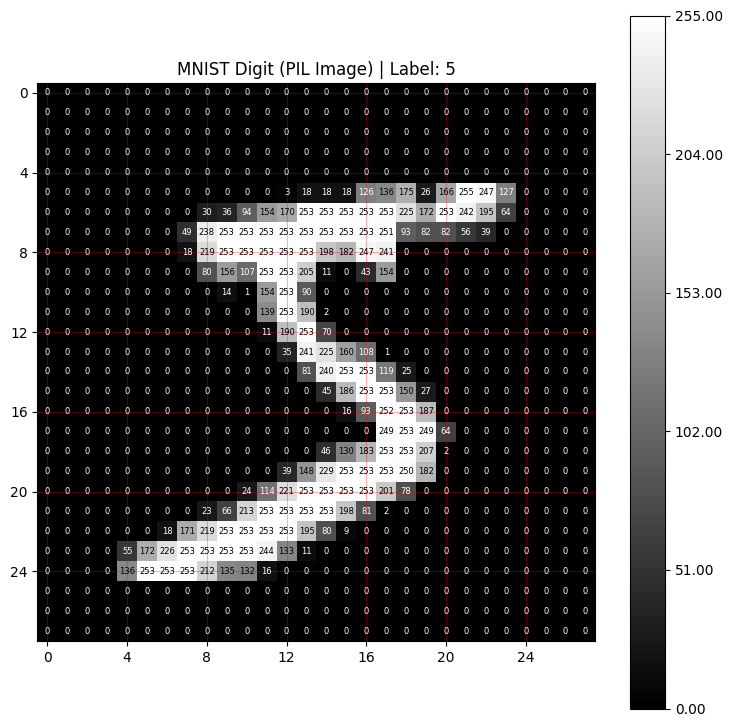

In [ ]:
display_image(image_pill, label, "MNIST Digit (PIL Image)", show_values=True)

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,),(0.3081,))
])

In [ ]:
train_dataset = torchvision.datasets.MNIST(
    root=data_path,
    train=True,
    download=True,
    transform=transform
)

In [ ]:
#u can see there is ToTensor after transformation its optim
#for the model
#[1,28,28] pytorch structure [channel,height,width]

In [ ]:
image_tensor,label = train_dataset[0]
print(f"image Type:        {type(image_tensor)}")
print(f"image shape :       {image_tensor.shape}")
print(f"type:               {type(label)}")
print(f"Label value:                  {label}")

image Type:        <class 'torch.Tensor'>
image shape :       torch.Size([1, 28, 28])
type:               <class 'int'>
Label value:                  5


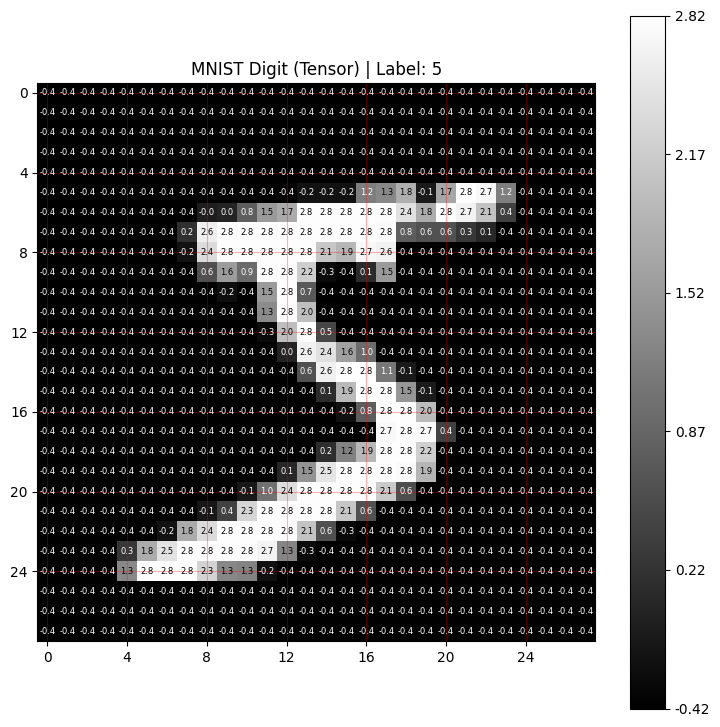

In [ ]:
display_image(image_tensor, label, "MNIST Digit (Tensor)", show_values=True)

In [ ]:
test_dataset = torchvision.datasets.MNIST(
    root = data_path,
    train=False,
    download=True,
    transform = transform
)

In [ ]:
#creating data loader
# using batch takes chunk of datasets
train_loader  = DataLoader(train_dataset,batch_size=64,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=1000 , shuffle=False)

In [ ]:
#nn.Flatten(): This layer's job is to transform the 2D image data (28x28 pixels) into a 1D vector of 784 elements (28 * 28 = 784).
# This reshaping step is required before passing the data into linear layers,
#which expect flat vectors rather than grids.

In [ ]:
#define model
class SimpleMNISTDNN(nn.Module):
      def __init__(self):
        super(SimpleMNISTDNN,self).__init__()

        self.flatten = nn.Flatten()
        self.layer = nn.Squential(
            nn.Linear(784,128),
            nn.ReLU(),
            nn.Linear(128,10)
        )

      def forward(self,x):
          x = self.flatten(x)
          x = self.layer(x)
          return x


In [ ]:
#init the NN model
model = SimpleMNISTDNN()
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)



In [ ]:
#training time
def train_epochs(model,loss_function,optimizer,train_loader,device):
  #model on correct device
  model = model.to(device)
  #set the model to training mode
  model.train()
  #init the track for the entire epoch loss
  epoch_loss = 0.0
  #init track for perodic progress reporting
  running_loss = 0.0
  num_correct_prediction = 0
  total_prediction= 0
  total_batches = len(training_loader)



  #iterative over the training data in batch
  for batch_idx, (inputs,targets) in enumerate(train_loader):

      input,tragets = inputs.to(device),targets.to(device)
      optimizer.zero_grad()
      outputs = model(inputs)
      loss = loss_function(outputs,targets)
      loss = loss.backward()
      optimizer.step()


      #accumlate the loss for tracking and reporting
      loss_value = loss.item()
      epochs_loss += loss_value
      running_loss +=loss_value

#calculate accuracy metrices
_, prediction_indices = outputs.max(1) #_, show the index position but its throway
batch_size = targets.size(0)
total_prediction += batch_size
num_correct_in_batch = predicted_indices.eq(targets).sum().item()
num_correct_predictions += num_correct_in_batch

if(batch_idx+1) % 134 ==0 or (batch_idx + 1 ) == total_batches:
  avg_running_loss = running_loss / 134
  accuracy = 100. * num_correct_predictions / total_predictions

  print(f'\tstep {batch_idx + 1}/{total_batches} -Loss: {avg_running_loss:.3f} | Acc: {accuracy:.2f}% ')

  #reset the trackers for the next
  running_loss = 0.0
  num_correct_predictions = 0
  total_predictions = 0


# Calculate the average loss for the entire epoch
avg_epoch_loss = epoch_loss / total_batches
#Return the trained model and the average epoch loss
return model, avg_epoch_loss



